# BME 2080 — Week 10 Meeting Prep
## Neural Networks (MLP) for Cancer Drug Response Prediction

---

### What you're doing in this notebook

In class you ran **Elastic Net** or **Random Forest** on the cancer drug response
dataset and tuned one key hyperparameter. Now you'll do the same thing with a
**neural network (MLP — Multi-Layer Perceptron)**, the third algorithm type you
saw in the Week 9 Meeting Prep.

By the end of this notebook you will have:
- Run MLP on all 15 drugs and compared performance to EN and RF
- Explored how **alpha** (regularization strength) affects MLP performance
- Seen the full alpha curve — the same shape you helped build in class

---


## Key Concepts: Multi-layer Perceptron

**Multi-layer perceptrons** are a type of **neural network** that learns to make predictions by passing data through a series of layers, where each layer transforms the data a little further until a final prediction comes out the other end. This approach is particularly strong for modeling non-linear relationships.

In an MLP, the features of the dataset comprise the **input layer**, and the predicted outcome comprises the **output layer**. The layer(s) in between, called **hidden layers**, each contain nodes. Every node in one layer is connected to every node in the next, and each connection has a weight corresponding to the importance of that connection to the prediction. At each node, the incoming signals are multiplied by their weights, summed together, and passed through an activation function that introduces nonlinearity, allowing the network to learn patterns that a simple linear equation couldn't capture.

There are instructive similarities bewteen MLPs and the brain. Like the nodes (artificial neurons) in an MLP, neurons in your brain collect input signals, integrate them in the cell body, and fire the axon if the integrated signal exceeds the biological threshold. Synaptic connections in the brain can vary in strength, just as connections in an MLP possess varying weights. At the network level, the brain processes information in hierarchical levels, just as MLPs employ complex weighted layers to make predictions from inputs.

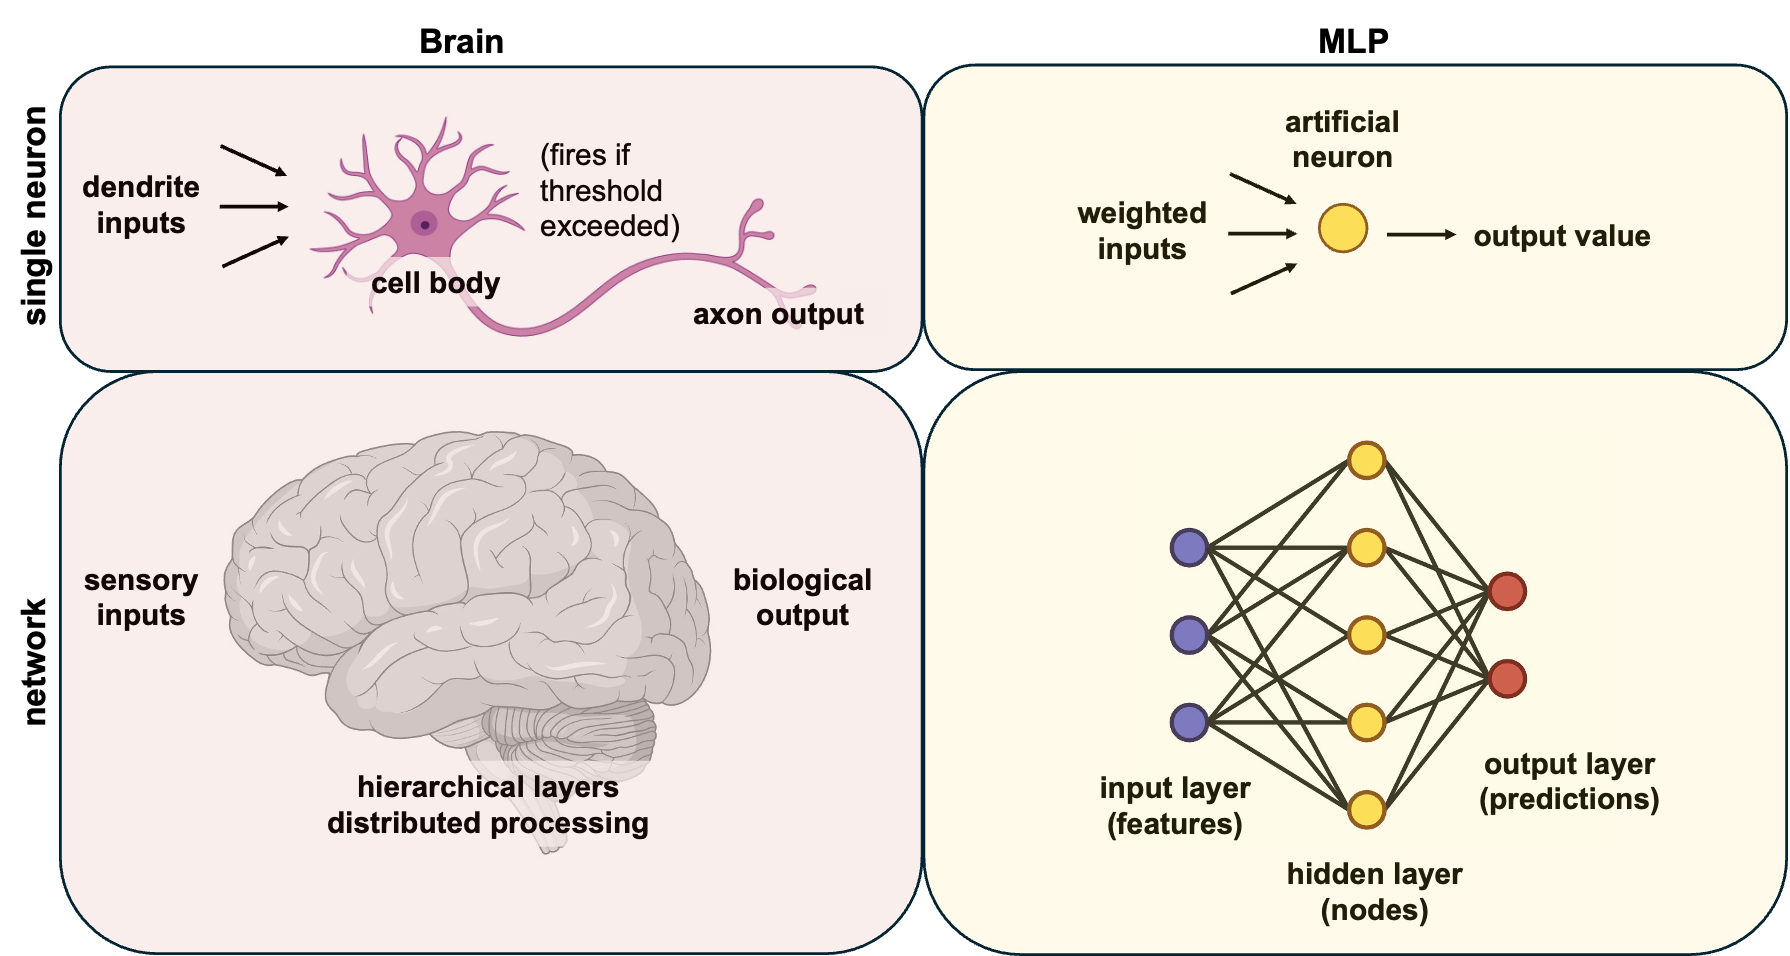

Importantly, the scale and complexity of biological neural networks far exceeds those of artificial ones, and not all algorithmic processes have biological equivalents. Nevertheless, observing the brain-inspired structure of MLPs may help to clarify the architecture.

##Algorithm Checklist: MLPs

Recall the important pieces of information we discussed in class. For any ML algorithm, make sure you understand the appropriate application, limitations, and data requirements before applying it to your problem.

For MLPs, note:
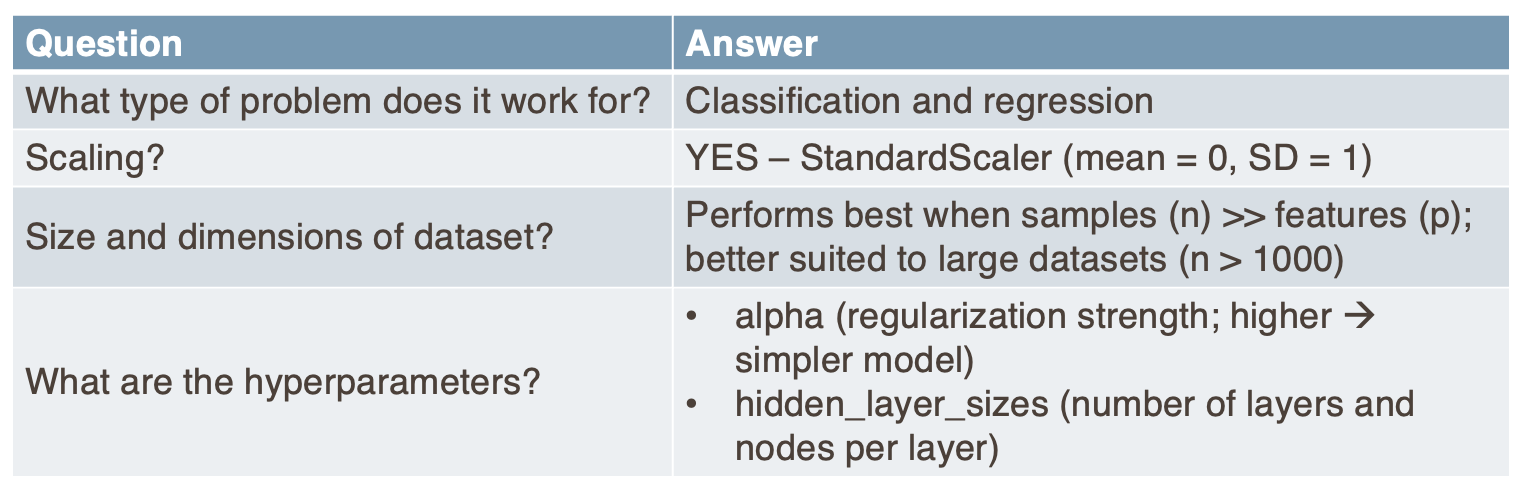

## Part 1: Setup


In [ ]:
# Block 1: Import all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

print('Libraries loaded successfully!')


In [ ]:
# Block 2: Load the same dataset you used in class
url = 'https://raw.githubusercontent.com/cr546-collab/bme2080-module3/main/teaching_multiomics_AUC_212lines.csv'
df = pd.read_csv(url)

feature_cols = ([c for c in df.columns if c.startswith('exp_')] +
                [c for c in df.columns if c.startswith('prot_')] +
                [c for c in df.columns if c.startswith('mut_')] +
                [c for c in df.columns if c.startswith('lineage_')])

drug_cols = sorted([c for c in df.columns if c.startswith('drug_')])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cancer_colors = {
    'Breast':                        '#e63946',
    'Colorectal':                    '#2a9d8f',
    'Lung Adenocarcinoma':           '#457b9d',
    'Lung Squamous Cell Carcinoma':  '#fb8500',
    'Ovary':                         '#8338ec',
    'Pancreas':                      '#06d6a0',
    'Skin':                          '#ffb703',
}

top4 = ['drug_Dabrafenib', 'drug_Vemurafenib', 'drug_Trametinib', 'drug_Afatinib']
top4_names = [d.replace('drug_', '') for d in top4]

print(f'Dataset loaded: {df.shape[0]} cell lines, {len(feature_cols)} features, {len(drug_cols)} drugs')


---
## Part 2: Run MLP on All 15 Drugs

### A quick reminder about MLP

You ran MLP on the breast cancer and diabetes datasets in the Week 9 prep notebook
and it worked well. Now you're running it on the cancer drug response data.

A few key facts about MLP for this dataset:
- ✅ Can learn nonlinear relationships between features and drug response
- ⚠️ **Requires feature scaling** — just like Elastic Net
- ⚠️ **Sensitive to the p≈n problem** — with 143 features and only 212 samples,
  it can struggle to learn reliably
- ⚠️ **alpha controls regularization** — the same concept as in Elastic Net.
  Too low → overfits. Too high → too simple. There's a sweet spot.

We're using the same architecture as the prep notebook:
`hidden_layer_sizes=(32, 16)` — two hidden layers with 32 and 16 neurons.

Run the cell below and compare the R² values to what your team saw in class.


In [ ]:
# Block 3: Run MLP on all 15 drugs ──────────────────────────────────────────────────
# This uses the same hidden_layer_sizes as the Week 9 prep notebook.
# alpha=0.01 is the prep notebook default — we'll explore this more in Part 3.
# This may take 2-3 minutes.

mlp_results = {}

for drug in drug_cols:
    name = drug.replace('drug_', '')
    valid = df[df[drug].notna()].reset_index(drop=True)
    y = valid[drug].values
    X = SimpleImputer(strategy='mean').fit_transform(valid[feature_cols])

    scores = []
    preds = np.zeros(len(y))

    for tr, te in kf.split(X):
        # MLP requires scaling — same as Elastic Net
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=(32, 16),  # same as prep notebook
                activation='relu',
                alpha=0.01,                   # regularization strength
                max_iter=1000,
                early_stopping=True,
                random_state=42
            ))
        ])
        pipe.fit(X[tr], y[tr])
        preds[te] = pipe.predict(X[te])
        scores.append(r2_score(y[te], preds[te]))

    mlp_results[name] = {
        'r2': np.mean(scores), 'preds': preds,
        'y': y, 'cancers': valid['disease'].values
    }
    print(f'{name:<20} CV R² = {np.mean(scores):>7.3f}')

print('\nDone!')


In [ ]:
# Block 4: Plot 1 - CV R² for all 15 drugs ──────────────────────────────────────────
# Compare this to what you saw in class with EN or RF.
# The dashed line marks R²=0.2 — our threshold for meaningful signal.

drugs = list(mlp_results.keys())
r2_vals = [mlp_results[d]['r2'] for d in drugs]
bar_colors = ['#7b5cf0' if d in top4_names else '#555555' for d in drugs]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(drugs, r2_vals, color=bar_colors, edgecolor='white', alpha=0.9)
ax.axhline(0, color='black', lw=1)
ax.axhline(0.2, color='gray', lw=1.5, linestyle='--', alpha=0.6,
           label='R²=0.2 threshold')
ax.set_ylabel('5-Fold CV R²', fontsize=12)
ax.set_title('MLP (alpha=0.01): CV R² Across All 15 Drugs\n'
             '(purple = top 4 drugs identified in class)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(drugs, rotation=35, ha='right', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for x, (drug, val) in enumerate(zip(drugs, r2_vals)):
    if drug in top4_names:
        ax.text(x, max(val, 0) + 0.008, f'{val:.2f}', ha='center',
                fontsize=9, fontweight='bold', color='#7b5cf0')

plt.tight_layout()
plt.show()

print('\nTop 4 drugs from class:')
print(f'{"Drug":<20} {"MLP R²":>8}')
print('-' * 30)
for d in top4_names:
    print(f'{d:<20} {mlp_results[d]["r2"]:>8.3f}')


In [ ]:
# Block 5: Plot 2 - Predicted vs. Actual AUC — top 4 drugs ──────────────────────────
# Same plot format as class. How does the scatter pattern compare?

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('MLP: Predicted vs. Actual AUC — Top 4 Drugs\n'
             '(dashed line = perfect prediction, colored by cancer type)',
             fontsize=13, fontweight='bold')

for ax, drug_name in zip(axes, top4_names):
    r = mlp_results[drug_name]
    for cancer in np.unique(r['cancers']):
        idx = np.where(r['cancers'] == cancer)[0]
        ax.scatter(r['y'][idx], r['preds'][idx],
                   color=cancer_colors[cancer], alpha=0.85,
                   edgecolors='white', linewidths=0.4, s=55, label=cancer)
    mn = min(r['y'].min(), r['preds'].min()) - 0.03
    mx = max(r['y'].max(), r['preds'].max()) + 0.03
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, alpha=0.5)
    rmse = np.sqrt(np.mean((r['y'] - r['preds'])**2))
    ax.text(0.04, 0.96,
            f'CV R² = {r["r2"]:.3f}\nRMSE = {rmse:.3f}\nn = {len(r["y"])}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_title(drug_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual AUC', fontsize=10)
    ax.set_ylabel('Predicted AUC', fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)

handles = [mpatches.Patch(color=v, label=k) for k, v in cancer_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=7,
           fontsize=9, bbox_to_anchor=(0.5, -0.06), framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Part 3: Tune MLP — The Alpha Sweep

Just like in class, you're going to tune the key hyperparameter for this algorithm.
For MLP, that's **alpha** — the regularization strength.

- **Too low alpha (e.g. 0.001)** → model overfits to training data → poor CV R²
- **Too high alpha (e.g. 100)** → model is too simple → also poor CV R²
- **Sweet spot** → best CV R² for Dabrafenib

### Step 1: Try a few values manually

Change the `alpha` value below, run the cell, and note what happens.
Try at least 3-4 different values before moving on.

**Suggested values to try first:** `0.001, 0.1, 1.0, 10.0`


In [ ]:
# Block 6: Manual tuning
# ┌──────────────────────────────────────────────────┐
# │  >>> CHANGE THIS VALUE, THEN RUN THE CELL <<<    │
# └──────────────────────────────────────────────────┘

alpha = 1.0   # try: 0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0

# ── Everything below runs automatically ──────────────────────────────────
drug = 'drug_Dabrafenib'
valid = df[df[drug].notna()].reset_index(drop=True)
y = valid[drug].values
X = SimpleImputer(strategy='mean').fit_transform(valid[feature_cols])

scores = []
for tr, te in kf.split(X):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation='relu',
            alpha=alpha,
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ])
    pipe.fit(X[tr], y[tr])
    scores.append(r2_score(y[te], pipe.predict(X[te])))

cv_r2 = np.mean(scores)
print(f'alpha  = {alpha}')
print(f'CV R²  = {cv_r2:.4f}')
print(f'\n→ Note this down, then change alpha above and run again!')
print(f'\nFor reference — default alpha=0.01: '
      f'CV R²={mlp_results["Dabrafenib"]["r2"]:.4f}')


### Step 2: See the full curve

Now run the cell below. It automatically sweeps alpha across a wide range,
computes CV R² for each value, and plots the full curve.

Look for:
- Where is the peak? That's the sweet spot.
- What happens at very low alpha?
- What happens at very high alpha?
- How does the shape of this curve compare to what you saw in class?


In [ ]:
# Block 7: Automated alpha sweep — runs all values and plots the curve ──────────────
# This will take 2-3 minutes. The curve will appear when it finishes.

drug = 'drug_Dabrafenib'
valid = df[df[drug].notna()].reset_index(drop=True)
y = valid[drug].values
X = SimpleImputer(strategy='mean').fit_transform(valid[feature_cols])

alpha_values = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5,
                1.0, 5.0, 10.0, 25.0, 50.0, 100.0]
r2_values = []

print('Running sweep...')
for alpha in alpha_values:
    scores = []
    for tr, te in kf.split(X):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation='relu',
                alpha=alpha,
                max_iter=1000,
                early_stopping=True,
                random_state=42
            ))
        ])
        pipe.fit(X[tr], y[tr])
        scores.append(r2_score(y[te], pipe.predict(X[te])))
    r2_values.append(np.mean(scores))
    print(f'  alpha={alpha:<8} CV R²={np.mean(scores):.4f}')

# Find best alpha
best_idx = np.argmax(r2_values)
best_alpha = alpha_values[best_idx]
best_r2 = r2_values[best_idx]

# Plot the curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alpha_values, r2_values, 'o-', color='#7b5cf0',
        lw=2.5, markersize=8, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor='#7b5cf0')
ax.axvline(best_alpha, color='#ff9f43', lw=2, linestyle='--',
           label=f'Best alpha={best_alpha} (R²={best_r2:.3f})')
ax.axvline(0.01, color='gray', lw=1.5, linestyle=':',
           label='Default alpha=0.01 (prep notebook)')
ax.axhline(0, color='black', lw=0.8, alpha=0.4)
ax.set_xscale('log')
ax.set_xlabel('alpha (regularization strength) — log scale', fontsize=12)
ax.set_ylabel('5-Fold CV R²  (Dabrafenib)', fontsize=12)
ax.set_title('MLP: Effect of Alpha on Performance\n'
             'Too little regularization → overfits. '
             'Too much → too simple. Sweet spot in between.',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nBest alpha: {best_alpha}  →  CV R² = {best_r2:.4f}')
print(f'Default alpha (0.01): CV R² = {mlp_results["Dabrafenib"]["r2"]:.4f}')
print(f'\nFor comparison — in class you found:')
print(f'  Elastic Net best CV R² for Dabrafenib: ~0.49')
print(f'  Random Forest best CV R² for Dabrafenib: ~0.40')


## Summary

Now, you have completed training, testing, and tuning of three ML algorithms (elastic net, random forest, and MLP) with our cancer dataset from class. In Week 10, we will explore interpretation and biological meaning of the model predictions.

---
